# Titanic – Pipeline final – John Bouckaert & Hugo Fiévet

## Introduction

Ce notebook présente la conception complète d’un modèle de prédiction appliqué au dataset Titanic.

Il regroupe dans un seul pipeline les étapes essentielles : préparation des données brutes, prétraitement, sélection des variables pertinentes et entraînement du modèle final retenu.

Après les essais réalisés dans les notebooks précédents, nous avons retenu la combinaison **SelectKBest + Decision Tree**, car elle donnait les meilleurs résultats, notamment sur le F1-score.

L’objectif est donc de produire une version finale plus propre, plus lisible et plus directement réutilisable.


## 1. Chargement des librairies

Nous importons les librairies nécessaires au chargement des données, au prétraitement, à la création du pipeline et à l’évaluation du modèle.


In [25]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt


## 2. Chargement du dataset

Nous repartons du dataset brut afin que le pipeline prenne en charge toutes les étapes de transformation.


In [26]:
dataset_path = Path("Titanic Dataset.csv")

if not dataset_path.exists():
    dataset_path = Path("Titanic Dataset(1).csv")

df = pd.read_csv(dataset_path)

print("Fichier utilisé :", dataset_path)
print("Dimensions du dataset :", df.shape)
print("\nAperçu des premières lignes :")
display(df.head())

print("\nColonnes disponibles :")
print(df.columns.tolist())


Fichier utilisé : Titanic Dataset.csv
Dimensions du dataset : (1309, 11)

Aperçu des premières lignes :


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S



Colonnes disponibles :
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


## 3. Séparation entre variables explicatives et variable cible

La variable à prédire est `survived`. Nous séparons donc les variables explicatives (`X`) et la cible (`y`).


In [27]:
target = "survived"

X = df.drop(columns=[target])
y = df[target]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

print("\nRépartition de la variable cible :")
print(y.value_counts(normalize=True).round(3))

Dimensions de X : (1309, 10)
Dimensions de y : (1309,)

Répartition de la variable cible :
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


## 4. Séparation en jeu d'entraînement et jeu de test

Nous utilisons une séparation train/test avec `random_state=42` pour obtenir des résultats reproductibles. L’option `stratify=y` permet de conserver une proportion similaire de survivants et de non-survivants dans les deux jeux.


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)

print("\nRépartition de y_train :")
print(y_train.value_counts(normalize=True).round(3))

print("\nRépartition de y_test :")
print(y_test.value_counts(normalize=True).round(3))

Dimensions de X_train : (1047, 10)
Dimensions de X_test : (262, 10)
Dimensions de y_train : (1047,)
Dimensions de y_test : (262,)

Répartition de y_train :
survived
0    0.618
1    0.382
Name: proportion, dtype: float64

Répartition de y_test :
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


## 5. Feature engineering

Certaines variables brutes sont transformées afin de créer des informations plus utiles pour le modèle :

- extraction du titre depuis `name` ;
- regroupement des titres rares ;
- création de `has_cabin` ;
- création de `family_size` et `family_group`.

Ces transformations sont placées dans une classe compatible avec un pipeline `sklearn`.


In [29]:
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Cette classe reprend le feature engineering réalisé dans le notebook de preprocessing.
    Elle permet de créer de nouvelles variables à partir des colonnes brutes du dataset Titanic.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # 1. Extraction du titre à partir du nom
        X["title"] = X["name"].str.extract(r",\s*([^\.]+)\.", expand=False)

        # 2. Regroupement des titres rares
        common_titles = ["Mr", "Mrs", "Miss", "Master"]
        X["title_grouped"] = X["title"].apply(
            lambda x: x if x in common_titles else "Other"
        )

        # 3. Création d'une variable indiquant si la cabine est renseignée
        X["has_cabin"] = X["cabin"].notna().astype(int)

        # 4. Création de la taille de la famille
        X["family_size"] = X["sibsp"] + X["parch"] + 1

        # 5. Regroupement de la taille de la famille
        def group_family_size(size):
            if size == 1:
                return "alone"
            elif 2 <= size <= 4:
                return "small_family"
            else:
                return "large_family"

        X["family_group"] = X["family_size"].apply(group_family_size)

        # 6. Suppression des colonnes brutes devenues inutiles
        columns_to_drop = ["name", "title", "ticket", "cabin"]
        X = X.drop(columns=columns_to_drop, errors="ignore")

        return X

Vérification du feature engineering avant son intégration dans le pipeline final.


In [30]:
feature_engineer = TitanicFeatureEngineer()

X_train_fe = feature_engineer.fit_transform(X_train)

print("Dimensions après feature engineering :", X_train_fe.shape)

print("\nColonnes obtenues après feature engineering :")
print(X_train_fe.columns.tolist())

print("\nAperçu des premières lignes :")
display(X_train_fe.head())

Dimensions après feature engineering : (1047, 11)

Colonnes obtenues après feature engineering :
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'title_grouped', 'has_cabin', 'family_size', 'family_group']

Aperçu des premières lignes :


,pclass,sex,age,sibsp,parch,fare,embarked,title_grouped,has_cabin,family_size,family_group
999,3,female,NaN,0,0,7.7500,Q,Miss,0,1,alone
392,2,female,24.0,1,0,27.7208,C,Mrs,0,2,small_family
628,3,female,11.0,4,2,31.2750,S,Miss,0,7,large_family
1165,3,male,25.0,0,0,7.2250,C,Mr,0,1,alone
604,3,female,16.0,0,0,7.6500,S,Miss,0,1,alone


## 6. Imputation des valeurs manquantes

Les valeurs manquantes sont traitées dans une classe personnalisée compatible avec `sklearn`.

L’âge est imputé en priorité avec la médiane calculée par groupe `title_grouped` + `pclass`, ce qui est plus précis qu’une médiane globale. Les variables `fare` et `embarked` sont respectivement complétées par la médiane et le mode du jeu d’entraînement.


In [31]:
class TitanicMissingValueImputer(BaseEstimator, TransformerMixin):
    """
    Cette classe reprend la stratégie d'imputation utilisée dans le notebook de preprocessing.

    - age : imputation par médiane selon title_grouped et pclass
    - fare : imputation par médiane
    - embarked : imputation par mode
    """

    def fit(self, X, y=None):
        X = X.copy()

        # Médianes d'âge par groupe
        self.age_medians_by_group_ = X.groupby(
            ["title_grouped", "pclass"]
        )["age"].median()

        # Médianes de secours par titre
        self.age_medians_by_title_ = X.groupby("title_grouped")["age"].median()

        # Médiane globale de secours
        self.age_median_global_ = X["age"].median()

        # Imputation des autres variables
        self.fare_median_ = X["fare"].median()
        self.embarked_mode_ = X["embarked"].mode()[0]

        return self

    def transform(self, X):
        X = X.copy()

        def impute_age(row):
            if pd.notna(row["age"]):
                return row["age"]

            group_key = (row["title_grouped"], row["pclass"])

            if (
                group_key in self.age_medians_by_group_.index
                and pd.notna(self.age_medians_by_group_.loc[group_key])
            ):
                return self.age_medians_by_group_.loc[group_key]

            if (
                row["title_grouped"] in self.age_medians_by_title_.index
                and pd.notna(self.age_medians_by_title_.loc[row["title_grouped"]])
            ):
                return self.age_medians_by_title_.loc[row["title_grouped"]]

            return self.age_median_global_

        X["age"] = X.apply(impute_age, axis=1)

        X["fare"] = X["fare"].fillna(self.fare_median_)
        X["embarked"] = X["embarked"].fillna(self.embarked_mode_)

        return X

Vérification rapide : après imputation, il ne doit plus rester de valeurs manquantes.


In [32]:
missing_value_imputer = TitanicMissingValueImputer()

X_train_imputed = missing_value_imputer.fit_transform(X_train_fe)

print("Valeurs manquantes après imputation :")
print(X_train_imputed.isna().sum())

print("\nAperçu des données après imputation :")
display(X_train_imputed.head())

Valeurs manquantes après imputation :
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
title_grouped    0
has_cabin        0
family_size      0
family_group     0
dtype: int64

Aperçu des données après imputation :


,pclass,sex,age,sibsp,parch,fare,embarked,title_grouped,has_cabin,family_size,family_group
999,3,female,18.0,0,0,7.7500,Q,Miss,0,1,alone
392,2,female,24.0,1,0,27.7208,C,Mrs,0,2,small_family
628,3,female,11.0,4,2,31.2750,S,Miss,0,7,large_family
1165,3,male,25.0,0,0,7.2250,C,Mr,0,1,alone
604,3,female,16.0,0,0,7.6500,S,Miss,0,1,alone


## 7. Encodage et standardisation

Les variables catégorielles sont encodées avec `OneHotEncoder`, les variables numériques sont standardisées avec `StandardScaler`, et la variable binaire `has_cabin` est conservée telle quelle.


In [33]:
categorical_columns = [
    "pclass",
    "sex",
    "embarked",
    "title_grouped",
    "family_group"
]

numerical_columns = [
    "age",
    "fare",
    "sibsp",
    "parch",
    "family_size"
]

binary_columns = [
    "has_cabin"
]

try:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", onehot_encoder, categorical_columns),
        ("bin", "passthrough", binary_columns)
    ],
    verbose_feature_names_out=False
)

Vérification du préprocesseur sur les données déjà passées par le feature engineering et l’imputation.


In [34]:
X_train_preprocessed = preprocessor.fit_transform(X_train_imputed)

feature_names = preprocessor.get_feature_names_out()

X_train_preprocessed_df = pd.DataFrame(
    X_train_preprocessed,
    columns=feature_names,
    index=X_train_imputed.index
)

print("Dimensions après encodage et standardisation :", X_train_preprocessed_df.shape)

print("\nColonnes obtenues :")
print(X_train_preprocessed_df.columns.tolist())

print("\nAperçu des données prétraitées :")
display(X_train_preprocessed_df.head())

Dimensions après encodage et standardisation : (1047, 22)

Colonnes obtenues :
['age', 'fare', 'sibsp', 'parch', 'family_size', 'pclass_1', 'pclass_2', 'pclass_3', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'title_grouped_Master', 'title_grouped_Miss', 'title_grouped_Mr', 'title_grouped_Mrs', 'title_grouped_Other', 'family_group_alone', 'family_group_large_family', 'family_group_small_family', 'has_cabin']

Aperçu des données prétraitées :


,age,fare,sibsp,parch,family_size,pclass_1,pclass_2,pclass_3,sex_female,sex_male,...,embarked_S,title_grouped_Master,title_grouped_Miss,title_grouped_Mr,title_grouped_Mrs,title_grouped_Other,family_group_alone,family_group_large_family,family_group_small_family,has_cabin
999,-0.820265,-0.499246,-0.479571,-0.447597,-0.557940,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
392,-0.371539,-0.090614,0.510785,-0.447597,0.083293,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
628,-1.343779,-0.017890,3.481854,1.872374,3.289456,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1165,-0.296752,-0.509988,-0.479571,-0.447597,-0.557940,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
604,-0.969840,-0.501292,-0.479571,-0.447597,-0.557940,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 8. Sélection des variables avec SelectKBest

Nous utilisons `SelectKBest` avec `k=15`, car la combinaison **SelectKBest + Decision Tree** était la meilleure lors des essais précédents. L’objectif est de garder les variables les plus pertinentes pour prédire la survie.


In [35]:
selector = SelectKBest(score_func=f_classif, k=15)

X_train_selected = selector.fit_transform(X_train_preprocessed_df, y_train)

selected_features = X_train_preprocessed_df.columns[selector.get_support()]

print("Dimensions avant SelectKBest :", X_train_preprocessed_df.shape)
print("Dimensions après SelectKBest :", X_train_selected.shape)

print("\nVariables sélectionnées :")
for feature in selected_features:
    print("-", feature)

Dimensions avant SelectKBest : (1047, 22)
Dimensions après SelectKBest : (1047, 15)

Variables sélectionnées :
- fare
- parch
- pclass_1
- pclass_3
- sex_female
- sex_male
- embarked_C
- embarked_S
- title_grouped_Miss
- title_grouped_Mr
- title_grouped_Mrs
- family_group_alone
- family_group_large_family
- family_group_small_family
- has_cabin


## 9. Création du pipeline final complet

Le pipeline final regroupe toutes les étapes dans un seul objet :

1. feature engineering ;
2. imputation des valeurs manquantes ;
3. encodage et standardisation ;
4. sélection des variables ;
5. entraînement du modèle final.

Cette structure permet d’appliquer automatiquement les mêmes transformations aux données d’entraînement et de test.


In [36]:
# Recréation propre du préprocesseur pour le pipeline final

try:
    onehot_encoder_final = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot_encoder_final = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", onehot_encoder_final, categorical_columns),
        ("bin", "passthrough", binary_columns)
    ],
    verbose_feature_names_out=False
)

In [37]:
final_pipeline = Pipeline(
    steps=[
        ("feature_engineering", TitanicFeatureEngineer()),
        ("missing_values", TitanicMissingValueImputer()),
        ("preprocessing", preprocessor_final),
        ("selection", SelectKBest(score_func=f_classif, k=15)),
        ("model", DecisionTreeClassifier(
            criterion="entropy",
            max_depth=3,
            min_samples_leaf=1,
            min_samples_split=2,
            random_state=42
        ))
    ]
)

final_pipeline

,steps,"[('feature_engineering', ...), ('missing_values', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


Entraînement du pipeline complet directement sur les données brutes du jeu d’entraînement.


In [38]:
final_pipeline.fit(X_train, y_train)

print("Pipeline final entraîné avec succès.")

Pipeline final entraîné avec succès.


## 10. Évaluation du pipeline final

Le pipeline est évalué sur le jeu de test avec l’accuracy, le F1-score, la matrice de confusion et le rapport de classification.


In [39]:
y_pred = final_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy du pipeline final :", round(accuracy, 4))
print("F1-score du pipeline final :", round(f1, 4))

Accuracy du pipeline final : 0.855
F1-score du pipeline final : 0.8


L’accuracy obtenue est de **0.8550** : le modèle prédit correctement environ **85,5 %** des passagers du jeu de test.

Le F1-score est de **0.8000**. Cette métrique est importante ici, car elle tient compte à la fois de la précision et du rappel pour la classe des survivants.


In [40]:
cm = confusion_matrix(y_test, y_pred)

print("Matrice de confusion :")
print(cm)

Matrice de confusion :
[[148  14]
 [ 24  76]]


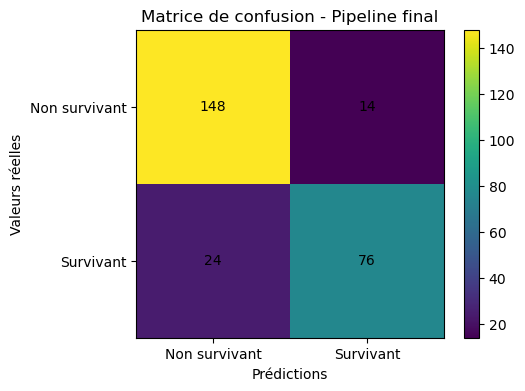

In [41]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matrice de confusion - Pipeline final")
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.xticks([0, 1], ["Non survivant", "Survivant"])
plt.yticks([0, 1], ["Non survivant", "Survivant"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [42]:
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       162
           1       0.84      0.76      0.80       100

    accuracy                           0.85       262
   macro avg       0.85      0.84      0.84       262
weighted avg       0.85      0.85      0.85       262



La matrice de confusion montre que le modèle prédit mieux les **non-survivants** que les **survivants**.

Il classe correctement **148** non-survivants et **76** survivants. En revanche, **24** survivants sont prédits à tort comme non-survivants, ce qui montre que cette classe reste plus difficile à reconnaître.


### Comparaison train / test

Cette vérification permet de contrôler rapidement si le modèle semble surapprendre les données d’entraînement.


In [43]:
y_pred_train = final_pipeline.predict(X_train)

accuracy_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

train_test_comparison_df = pd.DataFrame({
    "Jeu de données": [
        "Entraînement",
        "Test"
    ],
    "Accuracy": [
        accuracy_train,
        accuracy
    ],
    "F1-score": [
        f1_train,
        f1
    ]
})

display(train_test_comparison_df.round(4))

print("Écart accuracy train - test :", round(accuracy_train - accuracy, 4))
print("Écart F1-score train - test :", round(f1_train - f1, 4))

,Jeu de données,Accuracy,F1-score
0,Entraînement,0.7975,0.7218
1,Test,0.8550,0.8000


Écart accuracy train - test : -0.0574
Écart F1-score train - test : -0.0782


Les scores du jeu de test sont légèrement meilleurs que ceux du jeu d’entraînement : l’écart train - test est donc négatif.

Cela ne montre pas de surapprentissage. Le jeu de test semble simplement un peu plus facile à prédire dans ce découpage, ce qui peut arriver avec un dataset relativement petit comme Titanic.


## 11. Validation croisée

La validation croisée donne une estimation plus stable des performances, car elle évalue le pipeline sur plusieurs découpages du jeu d’entraînement.


In [44]:
cv_scores = cross_val_score(
    final_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print("Scores F1 obtenus pour chaque fold :")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i} : {score:.4f}")

print("\nRésumé de la validation croisée :")
print(f"F1-score moyen en validation croisée : {cv_mean:.4f}")
print(f"Écart-type : {cv_std:.4f}")

print("\nComparaison avec le jeu de test :")
print(f"F1-score sur le jeu de test : {f1:.4f}")
print(f"F1-score moyen en validation croisée : {cv_mean:.4f}")
print(f"Différence absolue : {abs(f1 - cv_mean):.4f}")

Scores F1 obtenus pour chaque fold :
Fold 1 : 0.7607
Fold 2 : 0.7170
Fold 3 : 0.6887
Fold 4 : 0.7500
Fold 5 : 0.6892

Résumé de la validation croisée :
F1-score moyen en validation croisée : 0.7211
Écart-type : 0.0300

Comparaison avec le jeu de test :
F1-score sur le jeu de test : 0.8000
F1-score moyen en validation croisée : 0.7211
Différence absolue : 0.0789


Le F1-score moyen en validation croisée est de **0.7211**, avec un écart-type de **0.0300**.


## 12. Analyse des variables retenues par le pipeline

Nous affichons d’abord les variables conservées par `SelectKBest`, puis l’importance des variables réellement utilisées par l’arbre de décision final.


In [45]:
# Récupération des noms des variables après le prétraitement
feature_names = final_pipeline.named_steps["preprocessing"].get_feature_names_out()

# Récupération du masque de sélection de SelectKBest
selected_mask = final_pipeline.named_steps["selection"].get_support()

# Variables retenues par SelectKBest
selected_features = feature_names[selected_mask]

print("Variables sélectionnées par SelectKBest :")
for feature in selected_features:
    print("-", feature)

Variables sélectionnées par SelectKBest :
- fare
- parch
- pclass_1
- pclass_3
- sex_female
- sex_male
- embarked_C
- embarked_S
- title_grouped_Miss
- title_grouped_Mr
- title_grouped_Mrs
- family_group_alone
- family_group_large_family
- family_group_small_family
- has_cabin


`SelectKBest` conserve 15 variables sur les 22 variables obtenues après le prétraitement.

Les variables sélectionnées sont cohérentes avec l’analyse du Titanic : elles concernent notamment le sexe, la classe, le prix du billet, le port d’embarquement, le titre du passager et la composition familiale.

L’arbre de décision n’utilise cependant pas forcément toutes ces variables dans ses règles finales. C’est pourquoi nous analysons ensuite les importances du modèle.


In [46]:
# Récupération du modèle final entraîné
trained_tree = final_pipeline.named_steps["model"]

# Importance des variables utilisées par l'arbre
feature_importances = trained_tree.feature_importances_

importance_df = pd.DataFrame({
    "variable": selected_features,
    "importance": feature_importances
}).sort_values(by="importance", ascending=False)

display(importance_df)

,variable,importance
5,sex_male,0.617456
3,pclass_3,0.191966
0,fare,0.080395
14,has_cabin,0.063723
9,title_grouped_Mr,0.046460
1,parch,0.000000
2,pclass_1,0.000000
4,sex_female,0.000000
6,embarked_C,0.000000
7,embarked_S,0.000000


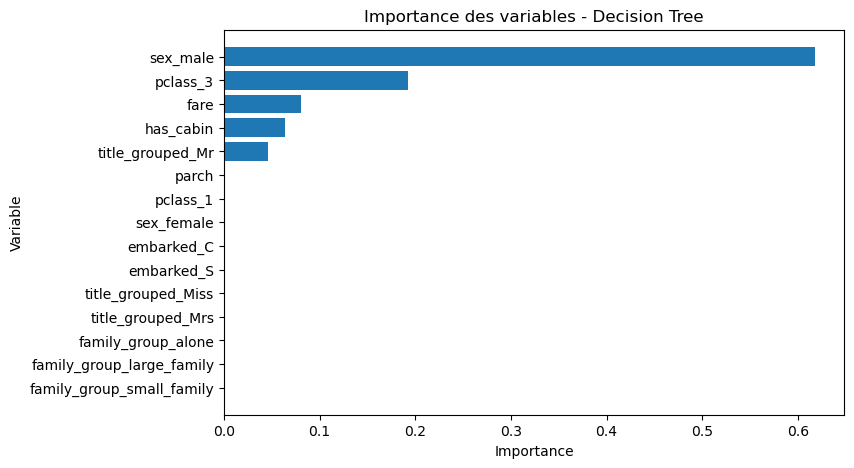

In [47]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df["variable"], importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Importance des variables - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

L’arbre de décision final utilise surtout quelques variables.

La plus importante est **`sex_male`**, suivie de **`pclass_3`**, **`fare`**, **`has_cabin`** et **`title_grouped_Mr`**.

Le modèle reste donc assez simple et interprétable : ses décisions reposent principalement sur le sexe, la classe, le prix du billet, la présence d’une cabine et le titre extrait du nom.


## 13. Résumé des performances

Le tableau suivant regroupe les principaux scores du pipeline final.


In [48]:
final_results = pd.DataFrame({
    "Métrique": [
        "Accuracy test",
        "F1-score test",
        "F1-score moyen en validation croisée",
        "Écart-type validation croisée"
    ],
    "Valeur": [
        round(accuracy, 4),
        round(f1, 4),
        round(cv_mean, 4),
        round(cv_std, 4)
    ]
})

display(final_results)

,Métrique,Valeur
0,Accuracy test,0.8550
1,F1-score test,0.8000
2,F1-score moyen en validation croisée,0.7211
3,Écart-type validation croisée,0.0300


Le score sur le jeu de test est bon : **0.8550** en accuracy et **0.8000** en F1-score.

La validation croisée donne toutefois un F1-score moyen plus bas, autour de **0.7211**. Cela indique que le score test est favorable et qu’il vaut mieux retenir la validation croisée comme estimation plus prudente de la performance générale.


## 14. Conclusion

Ce notebook final regroupe dans un seul pipeline les étapes nécessaires à la conception du modèle de prédiction : feature engineering, traitement des valeurs manquantes, encodage, standardisation, sélection des variables et entraînement du modèle final.

Le modèle retenu est un **Decision Tree** précédé d’une sélection de variables avec **SelectKBest**. Il obtient une accuracy de **0.8550** et un F1-score de **0.8000** sur le jeu de test.

La validation croisée donne une estimation plus prudente, avec un F1-score moyen de **0.7211**. Cela montre que le modèle fonctionne correctement, même si le score obtenu sur le jeu de test est probablement un peu optimiste.

Le pipeline final répond donc à l’objectif du travail : partir des données brutes du Titanic et appliquer automatiquement toutes les étapes nécessaires pour produire un modèle de prédiction complet, structuré et réutilisable.
